a. Implement Tabu search algorithm to solve the N-Queens problem.

In [19]:
import random

class TabuSearchNQueens:
    def __init__(self, n, max_iterations=10, tabu_tenure=10):
        self.n = n
        self.max_iterations = max_iterations
        self.tabu_tenure = tabu_tenure
        self.tabu_list = []  # Stores moves as (row1, row2) tuples

    def generate_initial_solution(self):
        """Generates a random permutation of columns."""
        solution = list(range(self.n))
        random.shuffle(solution)
        return solution

    def calculate_conflicts(self, solution):
        """
        Calculates the number of pairs of queens attacking each other.
        Since we use a permutation (1 queen per row/col), we only check diagonals.
        """
        conflicts = 0
        n = len(solution)
        for i in range(n):
            for j in range(i + 1, n):
                # Check diagonal attack: |row_diff| == |col_diff|
                if abs(i - j) == abs(solution[i] - solution[j]):
                    conflicts += 1
        return conflicts

    def get_neighbors(self, solution):
        """Generates all possible neighbors by swapping two rows."""
        neighbors = []
        for i in range(self.n):
            for j in range(i + 1, self.n):
                neighbor = solution[:]
                neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
                move = (i, j)
                neighbors.append((neighbor, move))
        return neighbors

    def solve(self):
        current_solution = self.generate_initial_solution()
        best_solution = current_solution[:]
        
        current_conflicts = self.calculate_conflicts(current_solution)
        best_conflicts = current_conflicts
        
        print(f"Initial Conflicts: {best_conflicts}")

        for iteration in range(self.max_iterations):
            if best_conflicts == 0:
                print(f"Solution found at iteration {iteration}!")
                break

            neighbors = self.get_neighbors(current_solution)
            best_neighbor = None
            best_neighbor_conflicts = float('inf')
            best_move = None

            # Iterate through neighbors to find the best allowed move
            for neighbor, move in neighbors:
                conflicts = self.calculate_conflicts(neighbor)
                
                # Aspiration Criterion: Allow tabu move if it improves the global best
                is_tabu = move in self.tabu_list
                if (not is_tabu) or (conflicts < best_conflicts):
                    if conflicts < best_neighbor_conflicts:
                        best_neighbor = neighbor
                        best_neighbor_conflicts = conflicts
                        best_move = move

            if best_neighbor is None:
                print("No valid moves found (stuck in local optima).")
                break

            # Move to the best neighbor found
            current_solution = best_neighbor
            current_conflicts = best_neighbor_conflicts

            # Update global best if needed
            if current_conflicts < best_conflicts:
                best_solution = current_solution[:]
                best_conflicts = current_conflicts

            # Update Tabu List
            self.tabu_list.append(best_move)
            if len(self.tabu_list) > self.tabu_tenure:
                self.tabu_list.pop(0)  # Remove oldest move

        return best_solution, best_conflicts

    def print_board(self, solution):
        for row in range(self.n):
            line = ""
            for col in range(self.n):
                if solution[row] == col:
                    line += "Q "
                else:
                    line += ". "
            print(line)

if __name__ == "__main__":
    N = 8  # Size of the board (8-Queens)
    solver = TabuSearchNQueens(n=N, max_iterations=500, tabu_tenure=5)
    
    solution, conflicts = solver.solve()
    
    print("\nFinal Solution (Column positions for each row):", solution)
    print("Final Conflicts:", conflicts)
    print("\nBoard Visualization:")
    solver.print_board(solution)

Initial Conflicts: 4
Solution found at iteration 4!

Final Solution (Column positions for each row): [4, 6, 1, 5, 2, 0, 7, 3]
Final Conflicts: 0

Board Visualization:
. . . . Q . . . 
. . . . . . Q . 
. Q . . . . . . 
. . . . . Q . . 
. . Q . . . . . 
Q . . . . . . . 
. . . . . . . Q 
. . . Q . . . . 


b. Implement Simulated Annealing algorithm to solve the Traveling Salesperson problem.

Initial Distance: 1180.88
Final Optimized Distance: 434.91
Best Tour Order: [10, 14, 19, 18, 16, 8, 5, 17, 12, 3, 9, 0, 4, 13, 6, 1, 11, 7, 2, 15]


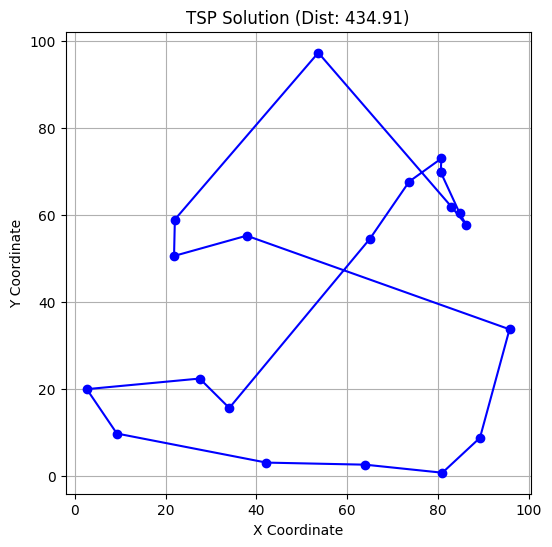

In [ ]:
import math
import random
import matplotlib.pyplot as plt

class SimulatedAnnealingTSP:
    def __init__(self, cities, initial_temp=1000, cooling_rate=0.995, stopping_temp=1e-8):
        self.cities = cities
        self.num_cities = len(cities)
        self.temp = initial_temp
        self.cooling_rate = cooling_rate
        self.stopping_temp = stopping_temp

    def get_distance(self, city_a, city_b):
        """Euclidean distance between two cities."""
        return math.sqrt((city_a[0] - city_b[0])**2 + (city_a[1] - city_b[1])**2)

    def calculate_total_distance(self, tour):
        """Calculates the total distance of the tour (including return to start)."""
        dist = 0
        for i in range(self.num_cities):
            from_city = self.cities[tour[i]]
            to_city = self.cities[tour[(i + 1) % self.num_cities]]
            dist += self.get_distance(from_city, to_city)
        return dist

    def generate_neighbor(self, tour):
        """
        Generates a neighbor solution.
        Method: Two-City Swap (swaps the positions of two random cities).
        """
        new_tour = tour[:]
        i, j = random.sample(range(self.num_cities), 2)
        new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
        return new_tour

    def solve(self):
        # 1. Start with a random solution
        current_solution = list(range(self.num_cities))
        random.shuffle(current_solution)
        
        current_dist = self.calculate_total_distance(current_solution)
        
        best_solution = current_solution[:]
        best_dist = current_dist
        
        print(f"Initial Distance: {current_dist:.2f}")

        # 2. Annealing Loop
        while self.temp > self.stopping_temp:
            # Generate a neighbor
            new_solution = self.generate_neighbor(current_solution)
            new_dist = self.calculate_total_distance(new_solution)

            # Calculate acceptance probability
            if new_dist < current_dist:
                # Always accept better solutions
                current_solution = new_solution
                current_dist = new_dist
                
                # Update global best
                if current_dist < best_dist:
                    best_solution = current_solution[:]
                    best_dist = current_dist
            else:
                # Accept worse solution with probability P = exp(-delta / T)
                delta = new_dist - current_dist
                probability = math.exp(-delta / self.temp)
                
                if random.random() < probability:
                    current_solution = new_solution
                    current_dist = new_dist

            # 3. Cool down
            self.temp *= self.cooling_rate

        return best_solution, best_dist

# --- Helper to Plot the Result ---
def plot_tour(cities, tour, title):
    x = [cities[i][0] for i in tour]
    y = [cities[i][1] for i in tour]
    # Connect back to start
    x.append(x[0])
    y.append(y[0])
    
    plt.figure(figsize=(6, 6))
    plt.plot(x, y, 'b-', marker='o')
    plt.title(title)
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.grid(True)
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    # Generate 20 random cities on a 100x100 grid
    num_cities = 20
    random.seed(42) # Fixed seed for reproducibility
    city_coords = [(random.uniform(0, 100), random.uniform(0, 100)) for _ in range(num_cities)]

    sa = SimulatedAnnealingTSP(city_coords, initial_temp=10000, cooling_rate=0.995)
    best_tour, min_distance = sa.solve()

    print(f"Final Optimized Distance: {min_distance:.2f}")
    print(f"Best Tour Order: {best_tour}")
    
    # Plotting (requires matplotlib)
    try:
        plot_tour(city_coords, best_tour, f"TSP Solution (Dist: {min_distance:.2f})")
    except ImportError:
        print("Install matplotlib to see the graph.")